# Chapter 3: The Tangent Space

**Source Span.** `An Introduction to Manifolds.pdf`, printed pages `86-163` (PDF pages `105-182`). This corrected span includes the tangent space, differentials, chain rule, coordinate bases, curves, immersions, submersions, rank and critical points, regular submanifolds and level sets, categories and functors, constant-rank theorems, embeddings, tangent planes, tangent bundles, vector bundles, sections, frames, bump functions, partitions of unity, vector fields, integral curves, local flows, Lie brackets, pushforwards, and related vector fields.

**Chapter Goal.** Build the differential calculus of manifolds from tangent vectors upward. The chapter starts with tangent vectors as derivations, turns smooth maps into linear maps on tangent spaces, detects submanifolds through rank, packages all tangent spaces into a bundle, and ends with vector fields as dynamical objects whose flows and brackets measure infinitesimal motion.

The corrected source span is much broader than the old notebook suggested. This notebook therefore avoids a single tangent-plane picture and instead follows the chapter's chain of ideas: differential via curves, rank as a local normal form detector, submanifolds as regular level sets, tangent bundles and partitions of unity as global scaffolding, and Lie brackets as the failure of two infinitesimal motions to commute.

## Visual Storyboard

1. **Differential and rank detector.** A rank heatmap for a smooth map shows where the differential is full rank and where critical behavior appears. Inspection target: determinant or singular-value data marks immersions/submersions locally.
2. **Differential through curves.** A parametric curve is pushed through a smooth map. Inspection target: differentiating the image curve gives the same vector as applying the Jacobian to the source velocity.
3. **Regular and critical level sets.** Contours of two functions compare a regular level set with a critical crossing. Inspection target: nonzero gradient supports submanifold structure; gradient collapse signals danger.
4. **Tangent bundle, frames, and partitions of unity.** A vector field on the circle and a one-dimensional partition of unity show how local data becomes global. Inspection target: tangent vectors vary smoothly, while bump functions glue local formulas.
5. **Flows and Lie brackets.** Two vector fields are applied in opposite orders. Inspection target: the commutator displacement agrees to first order with the symbolic Lie bracket.

## Library Routing

| Chapter concept | Representation | Library | Why this route |
| --- | --- | --- | --- |
| Differential and rank | Jacobian determinant/singular-value heatmap | SymPy, NumPy, Matplotlib | rank is linear algebra at every point |
| Curves and pushforwards | parametric curve plus Jacobian check | SymPy, Matplotlib | the curve definition is the most inspectable test of `F_*` |
| Regular level sets | contour plots with gradient magnitudes | NumPy, Matplotlib | level sets are visual; regularity is a gradient invariant |
| Tangent bundle and partitions | vector-field arrows plus bump-function cover | NumPy, Matplotlib | shows smooth local-to-global assembly |
| Lie bracket | symbolic bracket and flow commutator | SymPy, NumPy, Matplotlib | the bracket is both algebraic and dynamical |

In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

BOOK_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "source_map.json").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate book root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib

UNIT_KEY = "chapter-03-the-tangent-space"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIG = ARTIFACT_ROOT / "figures"
CHECK = ARTIFACT_ROOT / "checks"
TABLE = ARTIFACT_ROOT / "tables"
created_artifacts = []

def keep(path):
    created_artifacts.append(Path(path))
    return path

print(f"Artifacts: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")

Artifacts: artifacts\chapter-03-the-tangent-space


## Translation Guide

A tangent vector at `p` is a derivation on germs, but a smooth map `F:N -> M` turns that derivation into a new derivation by composition with functions on the target. In coordinates this pushforward is represented by the Jacobian matrix. The chain rule says that these linear maps compose as expected, which is why tangent spaces form a functorial construction: smooth maps induce linear maps, and dual/multicovector constructions reverse or extend those maps.

Rank is the local diagnostic. Immersions have injective differentials, submersions have surjective differentials, regular points have maximal rank for the relevant target, and critical points are where the rank drops. Regular level set and constant-rank theorems turn these rank conditions into submanifold structure. A tangent plane to a surface in `R^3` is just the visible case of this principle.

The tangent bundle then collects all tangent spaces into one manifold. Sections of that bundle are vector fields. Bump functions and partitions of unity are the smooth glue that lets local constructions become global ones. Integral curves and local flows turn vector fields into motion; the Lie bracket measures the first noncommuting part of two such motions.

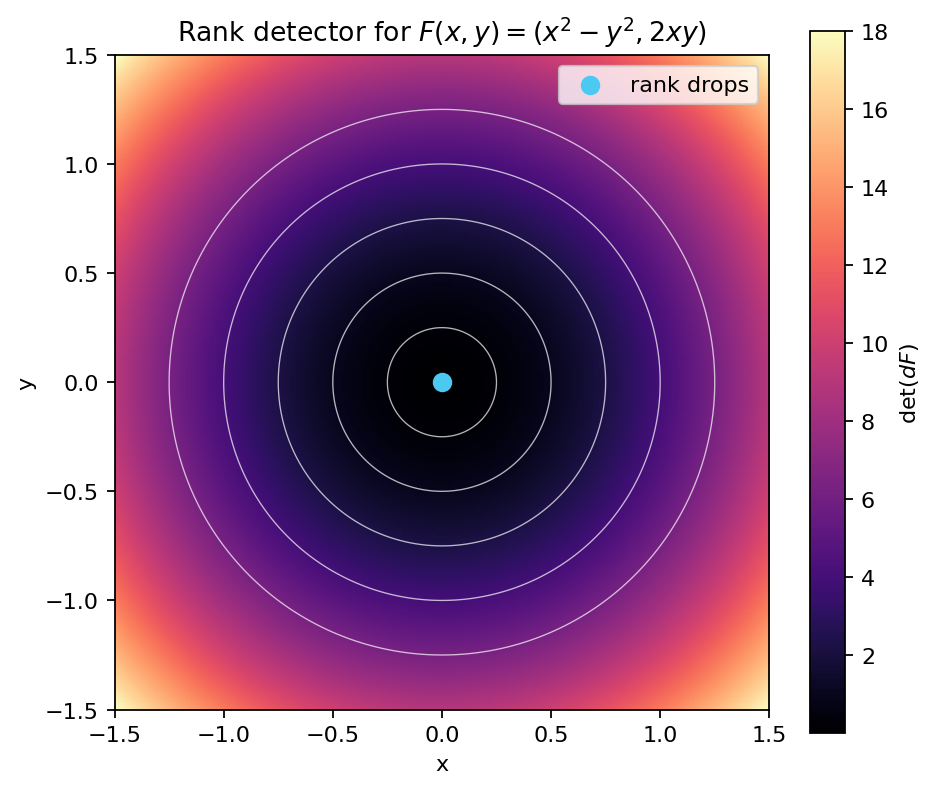

{'jacobian': 'Matrix([[2*x, -2*y], [2*y, 2*x]])',
 'determinant': '4*(x**2 + y**2)',
 'rank_at_origin': 0,
 'rank_at_1_0': 2,
 'critical_locus': 'origin only'}

In [2]:
# Rank detector for F(x,y) = (x^2 - y^2, 2xy), the complex squaring map.
x, y, t = sp.symbols("x y t", real=True)
F = sp.Matrix([x**2 - y**2, 2*x*y])
J = F.jacobian([x, y])
detJ = sp.factor(J.det())

xx = np.linspace(-1.5, 1.5, 260)
yy = np.linspace(-1.5, 1.5, 260)
XX, YY = np.meshgrid(xx, yy)
DET = 4 * (XX**2 + YY**2)
fig, ax = plt.subplots(figsize=(6.6, 5.7))
im = ax.imshow(DET, extent=[xx.min(), xx.max(), yy.min(), yy.max()], origin="lower", cmap="magma")
ax.contour(XX, YY, DET, levels=[0.25, 1.0, 2.25, 4.0, 6.25], colors="white", linewidths=0.6, alpha=0.7)
ax.scatter([0], [0], color="#4cc9f0", s=60, label="rank drops")
ax.set_title(r"Rank detector for $F(x,y)=(x^2-y^2,2xy)$")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="upper right")
fig.colorbar(im, ax=ax, label=r"det($dF$)")
rank_path = keep(save_matplotlib(fig, FIG / "differential-rank-detector.png"))
plt.close(fig)
rank_check = {
    "jacobian": str(J),
    "determinant": str(detJ),
    "rank_at_origin": int(J.subs({x: 0, y: 0}).rank()),
    "rank_at_1_0": int(J.subs({x: 1, y: 0}).rank()),
    "critical_locus": "origin only",
}
rank_check_path = keep(save_json(rank_check, CHECK / "rank-detector-check.json"))
display_artifact(rank_path, width=660)
rank_check

## Differentials Through Curves

The chapter repeatedly uses curves to identify tangent vectors. If `c(t)` is a curve through `p`, then its velocity `c'(0)` is a tangent vector at `p`. A smooth map `F` pushes it forward by sending the curve to `F(c(t))` and differentiating there. In coordinates, the same operation is multiplication by the Jacobian of `F` at `p`.

The next cell checks both descriptions. This is also the computational version of the chain rule: the map on tangent vectors is determined by how it acts on curves, and in charts it becomes the familiar derivative matrix.

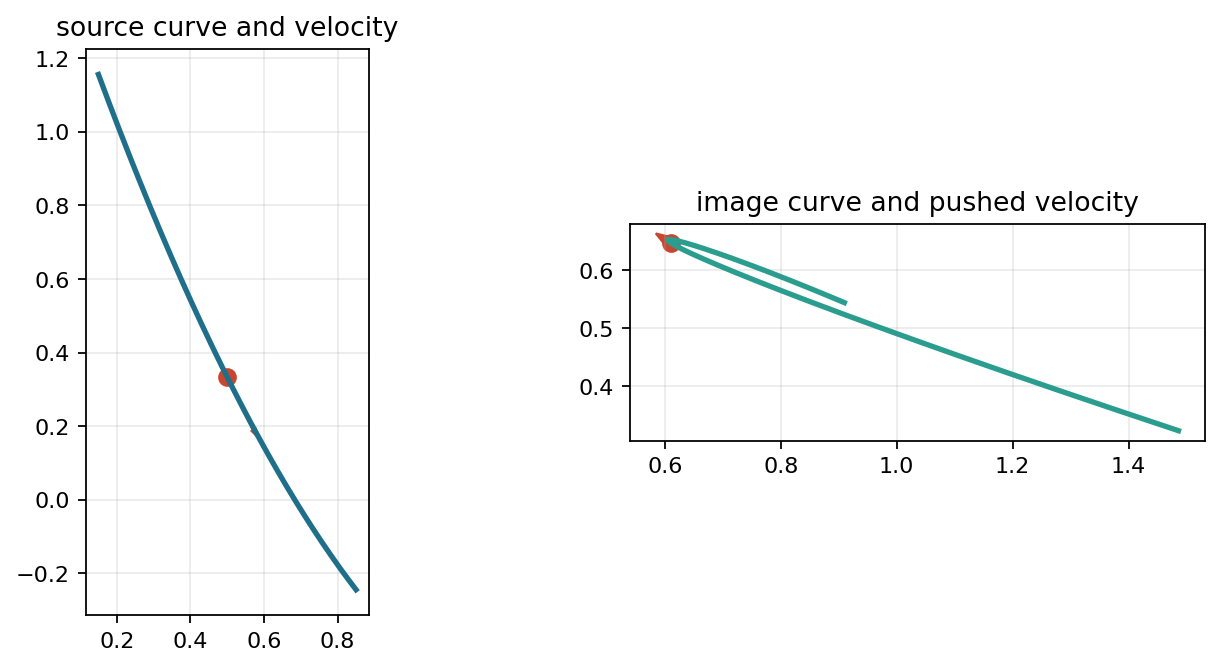

{'source_velocity': ['1', '-2'],
 'push_by_jacobian': ['-1/3', '-2/3 + cos(1/2)'],
 'image_curve_velocity': ['-1/3', '-2/3 + cos(1/2)'],
 'residual': ['0', '0']}

In [3]:
G = sp.Matrix([x + y**2, sp.sin(x) + x*y])
JG = G.jacobian([x, y])
curve = sp.Matrix([sp.Rational(1, 2) + t, sp.Rational(1, 3) - 2*t + t**2])
p0 = {x: sp.Rational(1, 2), y: sp.Rational(1, 3)}
velocity = sp.diff(curve, t).subs(t, 0)
push_by_jacobian = sp.simplify(JG.subs(p0) * velocity)
image_velocity = sp.simplify(sp.diff(G.subs({x: curve[0], y: curve[1]}), t).subs(t, 0))

T = np.linspace(-0.35, 0.35, 200)
curve_np = np.column_stack([0.5 + T, 1/3 - 2*T + T**2])
G_np = np.column_stack([curve_np[:,0] + curve_np[:,1]**2, np.sin(curve_np[:,0]) + curve_np[:,0]*curve_np[:,1]])
fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.6))
axes[0].plot(curve_np[:,0], curve_np[:,1], color="#1f6f8b", lw=2.4)
axes[0].scatter([0.5], [1/3], color="#c84630", s=55)
axes[0].arrow(0.5, 1/3, float(velocity[0])*0.08, float(velocity[1])*0.08, width=0.004, color="#c84630", length_includes_head=True)
axes[0].set_title("source curve and velocity")
axes[0].set_aspect("equal", adjustable="box")
axes[0].grid(alpha=0.25)
axes[1].plot(G_np[:,0], G_np[:,1], color="#2a9d8f", lw=2.4)
G0 = np.array([float(G[0].subs(p0)), float(G[1].subs(p0))])
axes[1].scatter([G0[0]], [G0[1]], color="#c84630", s=55)
axes[1].arrow(G0[0], G0[1], float(image_velocity[0])*0.08, float(image_velocity[1])*0.08, width=0.004, color="#c84630", length_includes_head=True)
axes[1].set_title("image curve and pushed velocity")
axes[1].set_aspect("equal", adjustable="box")
axes[1].grid(alpha=0.25)
curve_path = keep(save_matplotlib(fig, FIG / "differential-via-curves.png"))
plt.close(fig)
curve_check = {
    "source_velocity": [str(v) for v in velocity],
    "push_by_jacobian": [str(v) for v in push_by_jacobian],
    "image_curve_velocity": [str(v) for v in image_velocity],
    "residual": [str(v) for v in sp.simplify(push_by_jacobian - image_velocity)],
}
curve_check_path = keep(save_json(curve_check, CHECK / "differential-via-curves-check.json"))
display_artifact(curve_path, width=820)
curve_check

## Regular Level Sets, Submanifolds, and Constant Rank

A regular level set is the cleanest way to see a submanifold appear from equations. If `g:N -> R^m` has surjective differential along the level, the level set has the expected codimension. When the differential drops rank, the picture can acquire crossings, cusps, or singular points. Constant-rank theorems explain why stable rank gives local normal forms, while rank changes mark where those normal forms cannot be uniform.

The visual compares `x^2+y^2=1`, a regular circle, with `x^2-y^2=0`, whose zero level crosses at a critical point. The gradient magnitude plot is the invariant being inspected: nonzero gradient along the circle, zero at the crossing.

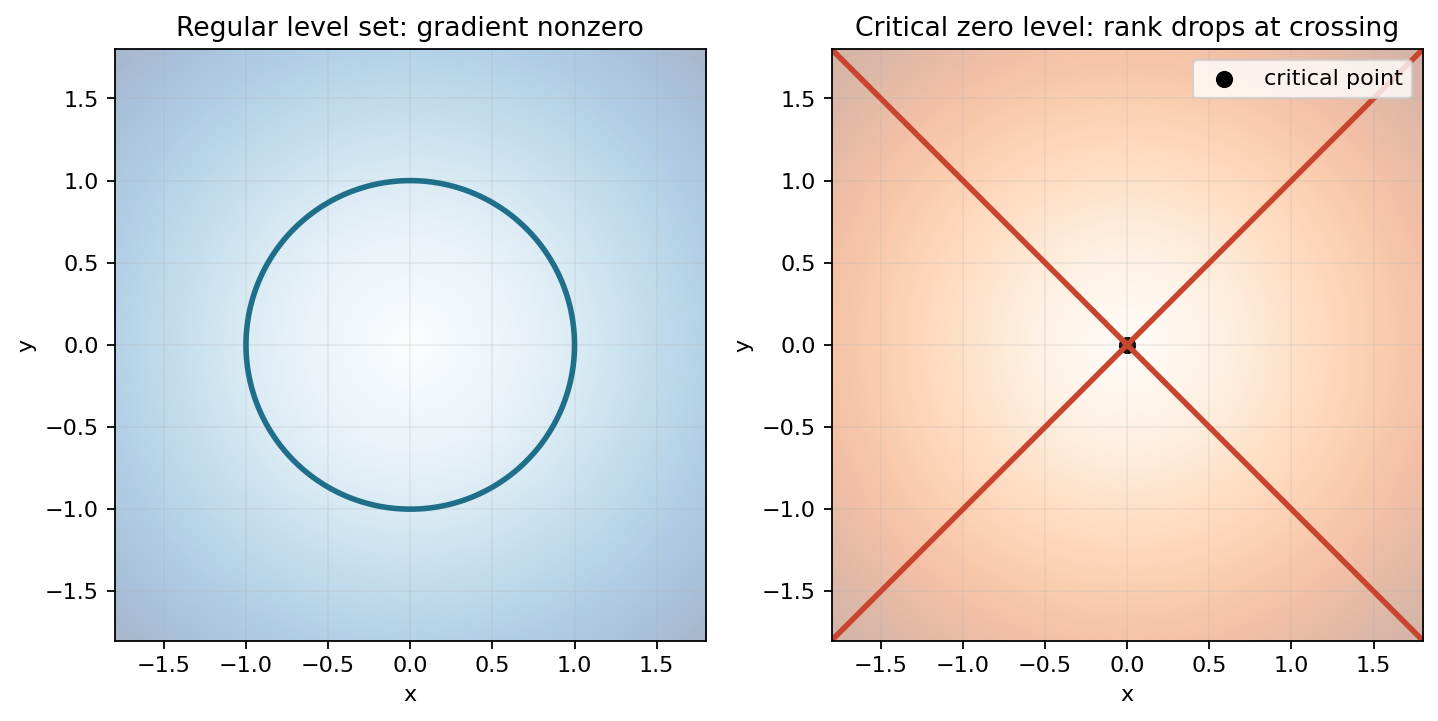

{'regular_gradient_on_unit_circle_min': 2.0,
 'critical_gradient_at_origin': 0.0,
 'regular_level_expected_dimension': 1,
 'critical_level_crossing_not_regular_at_origin': True}

In [4]:
grid = np.linspace(-1.8, 1.8, 320)
XX, YY = np.meshgrid(grid, grid)
regular = XX**2 + YY**2 - 1
critical = XX**2 - YY**2
grad_regular = np.sqrt((2*XX)**2 + (2*YY)**2)
grad_critical = np.sqrt((2*XX)**2 + (-2*YY)**2)
fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.8))
axes[0].contour(XX, YY, regular, levels=[0], colors=["#1f6f8b"], linewidths=2.5)
axes[0].imshow(grad_regular, extent=[grid.min(), grid.max(), grid.min(), grid.max()], origin="lower", cmap="Blues", alpha=0.35)
axes[0].set_title("Regular level set: gradient nonzero")
axes[1].contour(XX, YY, critical, levels=[0], colors=["#c84630"], linewidths=2.5)
axes[1].imshow(grad_critical, extent=[grid.min(), grid.max(), grid.min(), grid.max()], origin="lower", cmap="Oranges", alpha=0.35)
axes[1].scatter([0], [0], color="black", s=45, label="critical point")
axes[1].legend(loc="upper right")
axes[1].set_title("Critical zero level: rank drops at crossing")
for ax in axes:
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(alpha=0.2)
level_path = keep(save_matplotlib(fig, FIG / "regular-critical-level-sets.png"))
plt.close(fig)
level_check = {
    "regular_gradient_on_unit_circle_min": float(np.nanmin(np.abs(2*np.ones_like(theta := np.linspace(0, 2*np.pi, 200))))),
    "critical_gradient_at_origin": 0.0,
    "regular_level_expected_dimension": 1,
    "critical_level_crossing_not_regular_at_origin": True,
}
level_check_path = keep(save_json(level_check, CHECK / "regular-level-set-check.json"))
display_artifact(level_path, width=820)
level_check

## Tangent Bundles, Frames, and Partitions of Unity

The tangent bundle `TM` is the space of all tangent vectors at all points of `M`. A vector field is a section of this bundle. A smooth frame is a local basis of sections, and vector bundles generalize this local-triviality behavior. The source span also introduces bump functions and partitions of unity because they are the mechanism that lets local data become global smooth data.

The circle vector field below is a section of `TS^1`: at each point it assigns a tangent vector perpendicular to the radius. The bump functions show a finite partition on a line segment: nonnegative functions whose normalized sum is one where the cover is active. This is the computational model for gluing local formulas without creating nonsmooth seams.

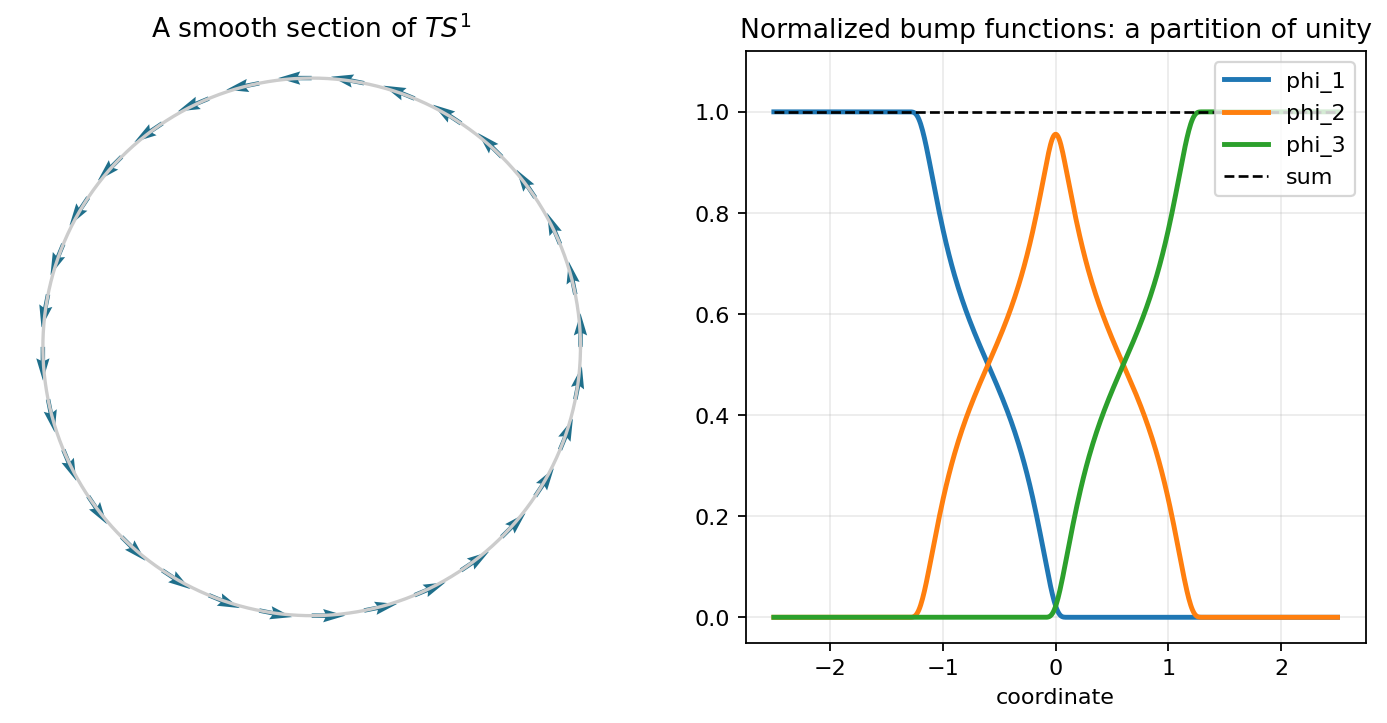

{'circle_tangent_dot_radius_max_abs': 0.0,
 'partition_min': 0.0,
 'partition_sum_max_error': 2.220446049250313e-16,
 'partition_nonnegative': True}

In [5]:
theta_vals = np.linspace(0, 2*np.pi, 32, endpoint=False)
points = np.column_stack([np.cos(theta_vals), np.sin(theta_vals)])
tangents = np.column_stack([-np.sin(theta_vals), np.cos(theta_vals)])
line = np.linspace(-2.5, 2.5, 600)
centers = np.array([-1.2, 0.0, 1.2])
raw = np.array([np.exp(-1.0 / np.maximum(1 - ((line-c)/1.35)**2, 1e-12)) * (np.abs(line-c) < 1.35) for c in centers])
partition = raw / raw.sum(axis=0)
partition_sum = partition.sum(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.8))
axes[0].plot(np.cos(np.linspace(0, 2*np.pi, 400)), np.sin(np.linspace(0, 2*np.pi, 400)), color="#cccccc")
axes[0].quiver(points[:,0], points[:,1], tangents[:,0], tangents[:,1], color="#1f6f8b", angles="xy", scale_units="xy", scale=8)
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_title(r"A smooth section of $TS^1$")
axes[0].axis("off")
for j, c in enumerate(centers):
    axes[1].plot(line, partition[j], lw=2.2, label=f"phi_{j+1}")
axes[1].plot(line, partition_sum, color="black", lw=1.2, ls="--", label="sum")
axes[1].set_ylim(-0.05, 1.12)
axes[1].set_title("Normalized bump functions: a partition of unity")
axes[1].set_xlabel("coordinate")
axes[1].grid(alpha=0.25)
axes[1].legend(loc="upper right")
bundle_path = keep(save_matplotlib(fig, FIG / "tangent-bundle-partition-unity.png"))
plt.close(fig)
bundle_check = {
    "circle_tangent_dot_radius_max_abs": float(np.max(np.abs(np.sum(points * tangents, axis=1)))),
    "partition_min": float(np.nanmin(partition)),
    "partition_sum_max_error": float(np.nanmax(np.abs(partition_sum - 1))),
    "partition_nonnegative": bool(np.nanmin(partition) >= -1e-12),
}
bundle_check_path = keep(save_json(bundle_check, CHECK / "bundle-partition-check.json"))
display_artifact(bundle_path, width=850)
bundle_check

## Applied Lab: Flows, Pushforwards, and Lie Brackets

A vector field can be read as a first-order differential operator, but it also drives integral curves. Local flows record the motion generated by a vector field. If two flows commute perfectly, moving first along `X` and then along `Y` agrees with the reverse order. In general they do not commute, and the leading discrepancy is measured by the Lie bracket `[X,Y]`.

This final experiment uses two polynomial vector fields on the plane. It computes the symbolic bracket and also compares two small Euler flow rectangles. The residual divided by `epsilon^2` approximates the bracket direction, making the algebraic definition visible as a motion defect.

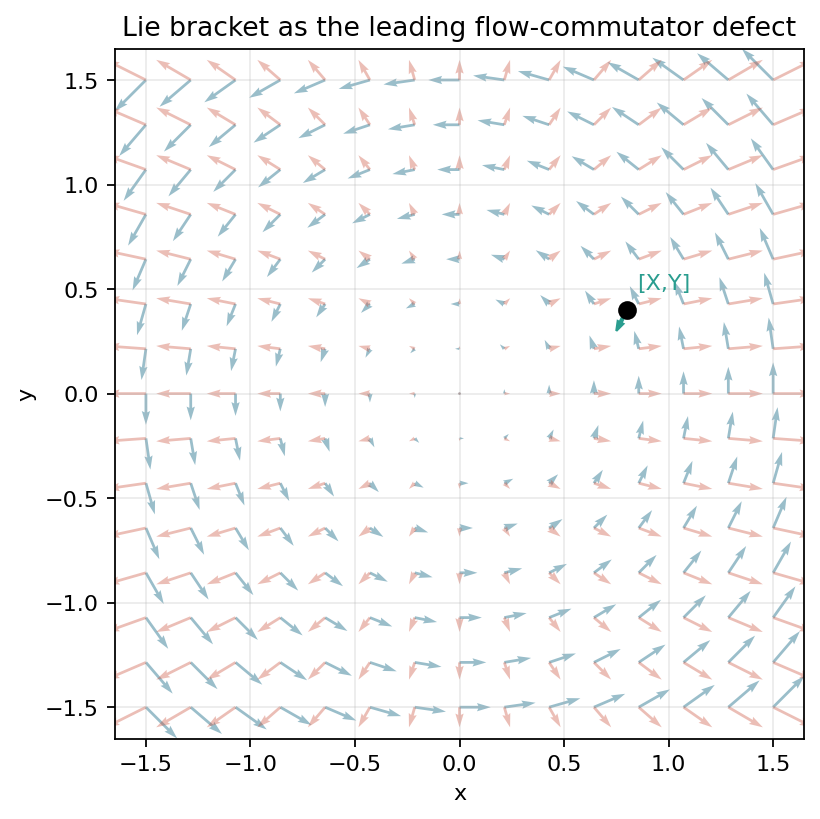

{'symbolic_bracket': ['-y/2', '-x/2'],
 'bracket_at_base': [-0.2, -0.4],
 'commutator_estimate': [-0.20000000000575113, -0.3999999999559911],
 'estimate_error_norm': 4.43830976013224e-11}

In [6]:
X = sp.Matrix([-y, x])          # rotation field
Y = sp.Matrix([x, sp.Rational(1, 2)*y])  # anisotropic dilation
vars_xy = sp.Matrix([x, y])
def bracket(A, B):
    return sp.simplify(B.jacobian(vars_xy) * A - A.jacobian(vars_xy) * B)
bracket_XY = bracket(X, Y)
base = np.array([0.8, 0.4], dtype=float)
eps = 1e-3

def X_num(p): return np.array([-p[1], p[0]], dtype=float)
def Y_num(p): return np.array([p[0], 0.5*p[1]], dtype=float)
forward_XY = base + eps*X_num(base)
forward_XY = forward_XY + eps*Y_num(forward_XY)
forward_YX = base + eps*Y_num(base)
forward_YX = forward_YX + eps*X_num(forward_YX)
commutator_estimate = (forward_XY - forward_YX) / eps**2
bracket_at_base = np.array([float(bracket_XY[0].subs({x: base[0], y: base[1]})), float(bracket_XY[1].subs({x: base[0], y: base[1]}))])

fig, ax = plt.subplots(figsize=(6.4, 5.6))
qgrid = np.linspace(-1.5, 1.5, 15)
QX, QY = np.meshgrid(qgrid, qgrid)
UX, VX = -QY, QX
UY, VY = QX, 0.5*QY
ax.quiver(QX, QY, UX, VX, color="#1f6f8b", alpha=0.45, label="X")
ax.quiver(QX, QY, UY, VY, color="#c84630", alpha=0.35, label="Y")
ax.scatter([base[0]], [base[1]], color="black", s=55, zorder=4)
scale = 0.25
ax.arrow(base[0], base[1], bracket_at_base[0]*scale, bracket_at_base[1]*scale, width=0.01, color="#2a9d8f", length_includes_head=True)
ax.text(base[0]+0.05, base[1]+0.1, "[X,Y]", color="#2a9d8f")
ax.set_aspect("equal", adjustable="box")
ax.set_title("Lie bracket as the leading flow-commutator defect")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(alpha=0.25)
flow_path = keep(save_matplotlib(fig, FIG / "flow-commutator-lie-bracket.png"))
plt.close(fig)
flow_check = {
    "symbolic_bracket": [str(v) for v in bracket_XY],
    "bracket_at_base": bracket_at_base.tolist(),
    "commutator_estimate": commutator_estimate.tolist(),
    "estimate_error_norm": float(np.linalg.norm(commutator_estimate - bracket_at_base)),
}
flow_check_path = keep(save_json(flow_check, CHECK / "flow-lie-bracket-check.json"))
# A small source-coverage ledger for the broad chapter span.
coverage_rows = [
    {"source_topic": "tangent vectors and differentials", "notebook_model": "curve pushforward and Jacobian"},
    {"source_topic": "rank, immersions, submersions", "notebook_model": "rank determinant heatmap"},
    {"source_topic": "submanifolds and level sets", "notebook_model": "regular versus critical contours"},
    {"source_topic": "tangent bundle, frames, partitions", "notebook_model": "circle vector field and bump partition"},
    {"source_topic": "flows, Lie brackets, pushforwards", "notebook_model": "flow commutator and symbolic bracket"},
    {"source_topic": "categories and functors", "notebook_model": "prose bridge: maps induce tangent and dual maps"},
]
coverage_path = keep(save_csv(coverage_rows, TABLE / "chapter-03-source-coverage-ledger.csv"))
display_artifact(flow_path, width=660)
flow_check

## Takeaways

- Tangent vectors are derivations, and smooth maps push tangent vectors forward by precomposing derivations with functions on the target.
- In coordinates, the differential is the Jacobian. The curve test and the matrix test must agree.
- Rank controls geometry. Full-rank or constant-rank hypotheses produce local normal forms, regular level sets, embeddings, immersions, and submersions.
- Tangent spaces assemble into the tangent bundle. Vector fields are sections, frames are local bases of sections, and partitions of unity glue local smooth constructions.
- Integral curves turn vector fields into local flows. Lie brackets measure the first noncommuting part of two infinitesimal motions.

The final sanity cell checks that the rank drop, curve pushforward, regular-level warning, tangent-vector orthogonality, partition identity, and Lie-bracket commutator all match their intended invariants.

In [7]:
# final_sanity
final_sanity = {
    "rank_drops_only_at_origin_model": rank_check["rank_at_origin"] == 0 and rank_check["rank_at_1_0"] == 2,
    "curve_pushforward_residual_zero": curve_check["residual"] == ["0", "0"],
    "critical_level_flagged": level_check["critical_level_crossing_not_regular_at_origin"],
    "circle_field_tangent": bundle_check["circle_tangent_dot_radius_max_abs"] < 1e-12,
    "partition_sums_to_one": bundle_check["partition_sum_max_error"] < 1e-12,
    "lie_bracket_flow_estimate_close": flow_check["estimate_error_norm"] < 0.01,
    "artifact_count": len(created_artifacts),
}
final_sanity_path = keep(save_json(final_sanity, CHECK / "final-sanity.json"))
assert final_sanity["rank_drops_only_at_origin_model"]
assert final_sanity["curve_pushforward_residual_zero"]
assert final_sanity["critical_level_flagged"]
assert final_sanity["circle_field_tangent"]
assert final_sanity["partition_sums_to_one"]
assert final_sanity["lie_bracket_flow_estimate_close"]
assert_artifacts(created_artifacts, min_bytes=40)
final_sanity

{'rank_drops_only_at_origin_model': True,
 'curve_pushforward_residual_zero': True,
 'critical_level_flagged': True,
 'circle_field_tangent': True,
 'partition_sums_to_one': True,
 'lie_bracket_flow_estimate_close': True,
 'artifact_count': 11}